# Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from google.colab import files
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Data loading/Reading

In [6]:
df = pd.read_csv('Mobiles Dataset (2025).csv', encoding='latin1')
print(f"Dataset Loaded: {df.shape[0]} rows")
df.head()

Dataset Loaded: 930 rows


,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


# Data Cleaning

In [7]:
# Extract numbers from text (e.g., "8 GB" -> 8) using regular expressions
df['RAM_num'] = pd.to_numeric(df['RAM'].str.extract(r'(\d+)')[0], errors='coerce')
df['Battery_num'] = pd.to_numeric(df['Battery Capacity'].str.extract(r'(\d+)')[0], errors='coerce')

In [8]:
# Extracting camera megapixels and screen size as floats/integers
df['Back_Cam_num'] = pd.to_numeric(df['Back Camera'].str.extract(r'(\d+)')[0], errors='coerce')
df['Front_Cam_num'] = pd.to_numeric(df['Front Camera'].str.extract(r'(\d+)')[0], errors='coerce')
df['Screen_num'] = pd.to_numeric(df['Screen Size'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# Missing values

In [9]:
# Remove non-numeric characters like "PKR" and commas to make the target variable usable
df['Price_num'] = df['Launched Price (Pakistan)'].str.replace(r'[^\d]', '', regex=True)
df['Price_num'] = pd.to_numeric(df['Price_num'], errors='coerce')

# Low and High Price logic

In [10]:
# Drop rows where critical data (Price, RAM, or Battery) is missing to ensure model quality
df_clean = df.dropna(subset=['Price_num', 'RAM_num', 'Battery_num']).copy()
print(f"Initial rows: {len(df)} | Rows after cleaning: {len(df_clean)}")

Initial rows: 930 | Rows after cleaning: 929


# Labeling

# Feature Selection

In [11]:
# Convert brands like 'Samsung' into numbers like 5 for the model to understand
le = LabelEncoder()
df_clean['Company_Enc'] = le.fit_transform(df_clean['Company Name'])

# Data Scaling

# Model Train/Apply

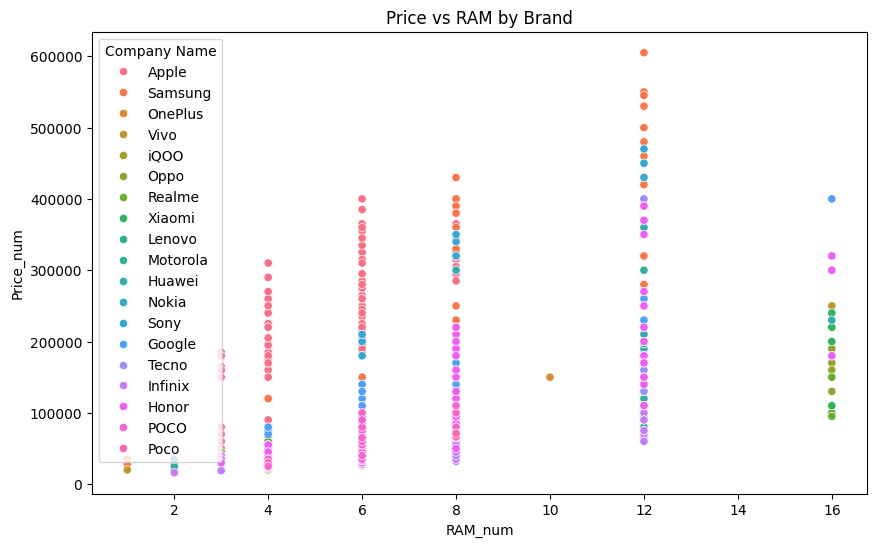

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='RAM_num', y='Price_num', hue='Company Name', data=df_clean)
plt.title("Price vs RAM by Brand")
plt.show()

C

In [13]:
# Choose which columns the AI will use to learn
features = ['Company_Enc', 'RAM_num', 'Battery_num', 'Back_Cam_num', 'Front_Cam_num', 'Screen_num']
X = df_clean[features].fillna(0) # Fill any remaining small gaps with 0
y = df_clean['Price_num']

In [14]:
# Split data: 80% for learning, 20% for testing the AI's "exam"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# max_depth=10 prevents the model from "memorizing" and helps it "generalize"
model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

print(f"Training Accuracy: {model.score(X_train, y_train)*100:.2f}%")
print(f"Test Accuracy: {model.score(X_test, y_test)*100:.2f}%")

Training Accuracy: 87.50%
Test Accuracy: 83.28%


In [16]:
# Save the 'brain' files
with open('model.pkl', 'wb') as f: pickle.dump(model, f)
with open('le.pkl', 'wb') as f: pickle.dump(le, f)
df_clean.to_csv('cleaned_data.csv', index=False)

# This will pop up the download dialog in your browser
files.download('model.pkl')
files.download('le.pkl')
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>